In [199]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import HumanMessage, SystemMessage


In [200]:
class AgentState(TypedDict):
    movie_name: str
    music_name: str
    recipy_name: str
    general_name: str
    query_type: str
    query:str


In [ ]:
def movie_agent(state: AgentState) -> AgentState:
    print("this is movie agent")
    state["movie_name"] = "Some movie result here"
    return state

def music_agent(state: AgentState) -> AgentState:
    print("this is music agent")
    state["music_name"] = "Some music result here"
    return state

def recipy_agent(state: AgentState) -> AgentState:
    print("this is recipy agent")
    state["recipy_name"] = "Some recipe result here"
    return state

def genral_agent(state: AgentState) -> AgentState:
    print("this is genral agent")
    state["general_name"] = "Some general result here"
    return state


In [202]:
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [203]:
load_dotenv()
llm = ChatGoogleGenerativeAI(
    model='gemini-2.0-flash',
    temperature=0.7,
    )

In [204]:
def question_classifier(state: AgentState) -> AgentState:
    query = state["query"]
    msg = [
        SystemMessage(content="In this project you have 4 agents: 1. movie_agent 2. music_agent 3. recipy_agent 4. genral_agent. Based on the following query, tell me which agent should be used. Just return one word: movie_agent, music_agent, recipy_agent, or genral_agent."),
        HumanMessage(content=query)
    ]
    result = llm(msg).content.strip().lower()
    print("The result is:", result)
    state["query_type"] = result
    return state  


In [205]:
def route_decision(state: AgentState) -> str:
    return state["query_type"]


In [206]:
graph = StateGraph(AgentState)
graph.add_node("movie_agent",movie_agent)
graph.add_node("music_agent",music_agent)
graph.add_node("recipy_agent",recipy_agent)
graph.add_node("genral_agent",genral_agent)
graph.add_node("question_classifier", question_classifier)
graph.add_node("router",lambda state:state)


In [207]:
graph.add_edge(START,"question_classifier")
graph.add_edge("question_classifier","router")
graph.add_conditional_edges(
    "router",
    route_decision,
    {
        "movie_agent":"movie_agent",
        "music_agent":"music_agent",
        "recipy_agent":"recipy_agent",
        "genral_agent":"genral_agent",
    }
)


In [ ]:
graph.add_edge("movie_agent","question_classifier")
graph.add_edge("music_agent","question_classifier")
graph.add_edge("recipy_agent","question_classifier")
graph.add_edge("genral_agent","question_classifier")
graph.add_edge("question_classifier",END)
# graph.add_edge("movie_agent",END)
# graph.add_edge("music_agent",END)
# graph.add_edge("recipy_agent",END)
# graph.add_edge("genral_agent",END)

In [209]:
app = graph.compile()

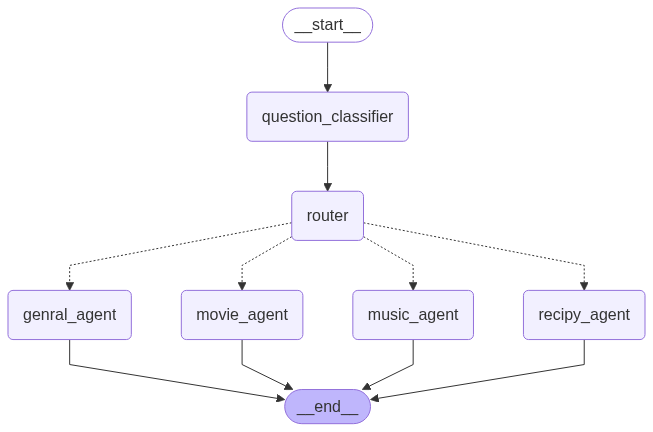

In [ ]:
from IPython.display import Image, display
app = input({
    "query":"recommend 10 hindi movie",
    "query2" : "recommend 20 hidni songs",
    "query3" : "recommend 4 maliyalam songs",
    "recipy": "I what to eat some spicy so recommend some spicey thing"
})
display(Image(app.get_graph().draw_mermaid_png()))

In [217]:
input_state = {
    "query": "recommend top 10 hindi movie",
    # "movie_name": "",
    # "music_name": "",
    # "recipy_name": "",
    # "general_name": "",
    # "query_type": ""
}

result = app.invoke(input_state)
print("Final Result:")
print(result)


The result is: movie_agent
this is movie agent
Final Result:
{'movie_name': 'Some movie result here', 'query_type': 'movie_agent', 'query': 'recommend top 10 hindi movie'}


In [212]:
# from typing import TypedDict
# from langgraph.graph import StateGraph,START,END
# class AgentState(TypedDict):
#     number1:int
#     operation:str
#     number2: int
#     finalNUmber:int
#     movie_name:str
#     music_name:str
    
# def adder(state: AgentState) -> AgentState:
#     """This node add the 2 numbers"""

#     state['finalNumber'] = state["number1"] + state["number2"]

#     return state

# def subractor(state:AgentState) -> AgentState:
#     """This nod subtracts the 2 numbers"""
#     state['finalNUmber'] = state['number1'] - state['number2']
#     return state


# def movie_agent(state: AgentState) -> AgentState:
#     print("this is movie agent")
#     state["movie_name"] = "Some movie result here"  # You can update this based on actual logic
#     return state

# def music_agent(state: AgentState) -> AgentState:
#     print("this is music agent")
#     state["music_name"] = "Some music result here"
#     return state


# # def decide_next_node (state:AgentState) -> AgentState:
# #     """This node will select the next ndoe of the graph"""

# #     if state["operation"] == "+":
# #         return "addition_operation"
# #     elif state["operation"] == "-":
# #         return "subtraction_operation"

# def question_classifier(state: AgentState) -> AgentState:
#     query = state["query"]
#     msg = [
#         SystemMessage(content="In this project you have 4 agents: 1. movie_agent 2. music_agent 3. recipe_agent 4. genral_agent. Based on the following query, tell me which agent should be used. Just return one word: movie_agent, music_agent, recipe_agent, or genral_agent."),
#         HumanMessage(content=query)
#     ]
#     result = llm(msg).content.strip().lower()
#     print("The result is:", result)
#     state["query_type"] = result
#     return state  

# graph = StateGraph(AgentState)
# graph.add_node("add_node", adder)
# graph.add_node("subtract_node", subractor)
# graph.add_node("movie_agent",movie_agent)
# graph.add_node("music_agent",music_agent)
# graph.add_node("router", lambda state:state)  #passthough function 

# graph.add_edge(START, "router")
# graph.add_conditional_edges(
#     "router",
#     question_classifier,

#     {
#         "movie_agent":"movie_agent",
#         "music_agent":"music_agent",
#         "addition_operation": "add_node",
#         "subtraction_operation": "subtract_node"
#     }
# )
# graph.add_edge("add_node", END)
# graph.add_edge("subtract_node", END)

# app = graph.compile()
# from IPython.display import Image, display

# display(Image(app.get_graph().draw_mermaid_png()))
# innitial_state_1 = AgentState(number1= 10, operation="-", number2= 5)
# print(app.invoke({"query":"recommend top 10 hindi movie"}))

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

# Load API keys (make sure .env file is set up)
load_dotenv()

# ---- Define the state type ----
class AgentState(TypedDict):
    movie_name: str
    music_name: str
    recipy_name: str
    general_name: str
    query_type: str
    query: str

# ---- Define agents ----
def movie_agent(state: AgentState) -> AgentState:
    print("this is movie agent")
    state["movie_name"] = "Inception, Dangal, 3 Idiots..."
    return state

def music_agent(state: AgentState) -> AgentState:
    print("this is music agent")
    state["music_name"] = "Arijit Singh playlist..."
    return state

def recipy_agent(state: AgentState) -> AgentState:
    print("this is recipe agent")
    state["recipy_name"] = "Butter Chicken, Palak Paneer..."
    return state

def genral_agent(state: AgentState) -> AgentState:
    print("this is general agent")
    state["general_name"] = "This is a general answer..."
    return state

# ---- Set up LLM ----
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    temperature=0.3
)

# ---- Classifier node: updates state with query_type ----
def question_classifier(state: AgentState) -> AgentState:
    query = state["query"]
    msg = [
        SystemMessage(content=(
            "You have 4 agents: movie_agent, music_agent, recipe_agent, and genral_agent. "
            "Based on the query, return only one word: movie_agent, music_agent, recipe_agent, or genral_agent."
        )),
        HumanMessage(content=query)
    ]
    result = llm.invoke(msg).content.strip().lower()
    print("The result is:", result)
    state["query_type"] = result
    return state

# ---- Router function: decides next node based on query_type ----
def route_decision(state: AgentState) -> str:
    return state["query_type"]

# ---- Build the graph ----
graph = StateGraph(AgentState)

# Add nodes
graph.add_node("question_classifier", question_classifier)
graph.add_node("router", lambda state: state)  # passthrough
graph.add_node("movie_agent", movie_agent)
graph.add_node("music_agent", music_agent)
graph.add_node("recipy_agent", recipy_agent)
graph.add_node("genral_agent", genral_agent)

# Define edges
graph.add_edge(START, "question_classifier")
graph.add_edge("question_classifier", "router")

graph.add_conditional_edges(
    "router",
    route_decision,
    {
        "movie_agent": "movie_agent",
        "music_agent": "music_agent",
        "recipe_agent": "recipy_agent",   # ⚠️ fix spelling to match LLM output
        "genral_agent": "genral_agent"
    }
)

# Connect agents to END
graph.add_edge("movie_agent", END)
graph.add_edge("music_agent", END)
graph.add_edge("recipy_agent", END)
graph.add_edge("genral_agent", END)

# Compile the graph
app = graph.compile()

# ---- Run the graph with test input ----
input_state = {
    "query": "recommend top 10 crecketer name",
    # "movie_name": "",
    # "music_name": "",
    # "recipy_name": "",
    # "general_name": "",
    # "query_type": ""
}

result = app.invoke(input_state)
print("Final Result:")
print(result)


The result is: genral_agent
this is general agent
Final Result:
{'general_name': 'This is a general answer...', 'query_type': 'genral_agent', 'query': 'recommend top 10 crecketer name'}
